<div style="
  text-align:center;
  border-radius:15px;
  padding:15px;
  color:#C6FFC6;
  margin:0;
  font-family:'Courier New', monospace;
  background:#041404;
  box-shadow:0px 0px 16px rgba(50,255,100,0.15);
  overflow:hidden;
  margin-bottom:1em;
  border:1px solid rgba(100,255,120,0.15);
">
  <div style="
    font-size:150%;
    color:#A9FFA9;
    text-shadow:0 0 8px rgba(140,255,160,0.4), 0 0 18px rgba(120,255,140,0.2);
  ">
    <b>Fallout New Vegas papyrus: exploring the Mojave Slang.</b>
  </div>
  <div style="
    color:#80EE9A;
    margin-top:6px;
    font-size:90%;
  ">
    A notebook by
    <a href='https://github.com/brooks-code' style='color:#99FFB3; text-decoration:none; border-bottom:1px dotted rgba(150,255,150,0.5);'>
      brkln
    </a>
  </div>
</div>


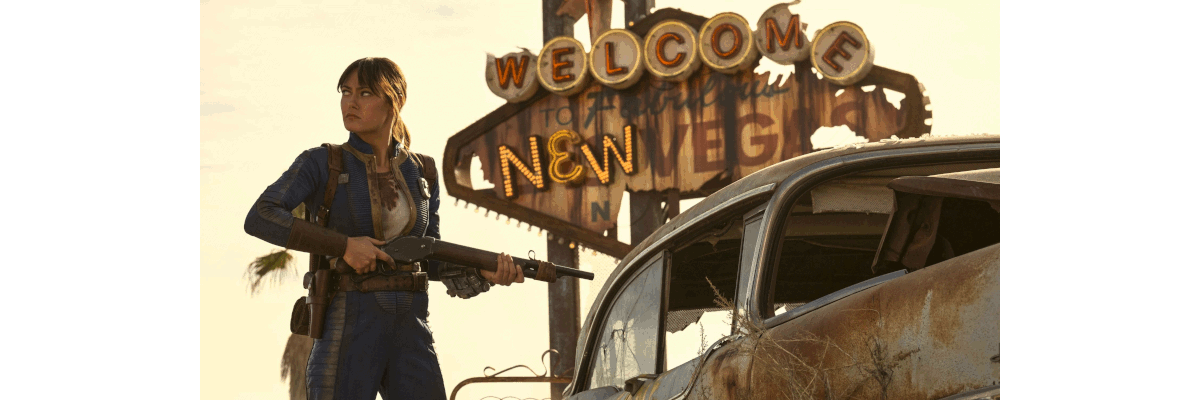

# <a id='toc1_'></a>[Fallout New Vegas dataset.](#toc0_)

## <a id='toc1_1_'></a>[An exploratory data analysis](#toc0_)

Welcome to the first instalment of our notebook series where we’ll dig into the Fallout: New Vegas dataset with *raw text* [extracted](https://github.com/brooks-code/new-vegas-papyri) from the game: dialog lines, NPC chatter, item descriptions, quest text, and more. This playground is possibility-rich and perfect for practising NLP, data science, and game analytics on a corpora teeming with Mojave-flavored lore.

In this part we’ll do a **classic exploratory data analysis (EDA**) and some light cleaning: check shape, missing values, duplicates, basic distributions, and perform a few pragmatic preprocessing steps so later parts can focus on modeling, topic extraction, narrative analysis and more.

What you’ll get in this notebook:

- A clean, reproducible EDA workflow you can run in Jupyter.
- Quick checks for data quality: missing values, duplicates, inconsistent types.
- Basic text cleaning and normalization tuned to game text.
- A few lightweight visualizations and summary tables.
- Export-ready cleaned data for downstream tasks (topic modeling, dialogue clustering, sentiment by faction, etc.).

Why this dataset is rad?

- **Authentic in-game text from Fallout: New Vegas**, perfect for story and character-driven NLP.
- **Dialogue-rich**: lots of short utterances, unique NPC voices, repeated lines (ideal for duplicate detection and bot-building).
- Great for interesting **analyses**: faction lexicons, quest-speech networks, motif extraction, or building a “Yes Man” chatbot.

The content has been extracted directly from the original Fallout New Vegas game. The text mining source code is available on [GitHub](https://github.com/brooks-code/new-vegas-papyri).

<div style="background-color:#041404; border-left:4px solid #38b86a; padding:18px; margin:20px auto; border-radius:10px; color:#b7fcb7; font-family:'Courier New', monospace; box-shadow:0 0 14px rgba(80,255,120,0.15); max-width:80%;">
  
  <div style="margin:12px 0;">
    <div style="background:rgba(0,40,0,0.3); border-left:3px solid rgba(140,255,160,0.35); padding:10px 12px; border-radius:6px;">
      <i>Wanderer:</i> What's to keep you from abusing your power?
    </div>
  </div>

  <div style="margin:12px 0;">
    <div style="background:rgba(5,25,5,0.45); border-left:3px solid rgba(180,255,190,0.25); padding:12px; border-radius:6px;">
      <i>Mr. House:</i> My judgement. I have no interest in abusing others, just as I have no interest in legislating or otherwise dictating what people do in their private time. Nor have I any interest in being worshipped as some kind of machine god messiah. I am impervious to such corrupting ambitions. But autocracy? Firm control in the hands of a technological and economic visionary? 
      <span style="color:#80ff9a; font-weight:bold;">Yes, that Vegas shall have.</span>
    </div>
  </div>

  <div style="margin-top:14px; font-size:0.9rem; color:#9EE7A8; opacity:0.9; text-align:right;">
    — Mr. House, *New Vegas, 2281 (in spirit)*
  </div>
</div>


**Table of contents**<a id='toc0_'></a>    
- [Fallout New Vegas dataset.](#toc1_)    
  - [An exploratory data analysis](#toc1_1_)    
  - [I. Environment & quick start](#toc1_2_)    
    - [Imports](#toc1_2_1_)    
  - [II. Load data](#toc1_3_)    
  - [III. Quick dataset summary](#toc1_4_)    
    - [A. Basics](#toc1_4_1_)    
    - [B. High cardinality features](#toc1_4_2_)    
    - [C. Visualizations](#toc1_4_3_)    
  - [IV. Data quality & cleaning](#toc1_5_)    
    - [A. Missing values](#toc1_5_1_)    
    - [B. Duplicates](#toc1_5_2_)    
    - [C. Inconsistent types / text cleaning checks](#toc1_5_3_)    
    - [D. Cleaning pipeline](#toc1_5_4_)    
  - [V. Text statistics](#toc1_6_)    
  - [Acknowledgments ☢](#toc1_7_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

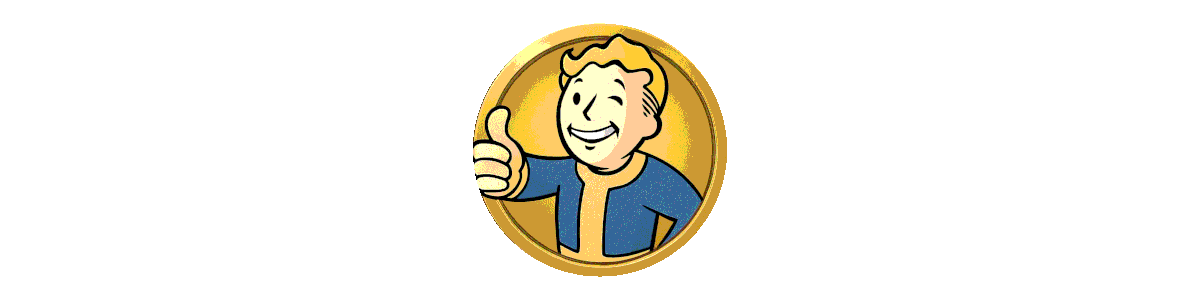

## <a id='toc1_2_'></a>[I. Environment & quick start](#toc0_)
- **Requirements:** Python 3.9+, pandas, numpy, matplotlib, seaborn, nltk

- Install:

```bash
pip install pandas numpy matplotlib seaborn nltk regex
```

### <a id='toc1_2_1_'></a>[Imports](#toc0_)

In [86]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

import re
import unicodedata
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import nltk
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords

## <a id='toc1_3_'></a>[II. Load data](#toc0_)

Semicolon delimiter, header present. Read as strings to inspect types.

In [87]:
df =  pd.read_csv("/kaggle/input/fallout-new-vegas-dataset/fallout_new_vegas_dataset.csv", sep=";", dtype=str, encoding="latin-1")
df.shape, df.memory_usage(deep=True).sum()

((53569, 12), np.int64(51293593))

## <a id='toc1_4_'></a>[III. Quick dataset summary](#toc0_)
### <a id='toc1_4_1_'></a>[A. Basics](#toc0_)
- Shape, file size:

In [88]:
rows, cols = df.shape
filesize = os.path.getsize("/kaggle/input/fallout-new-vegas-dataset/fallout_new_vegas_dataset.csv")
print("Total rows: " + str(rows), "\nNumber of features: " +
      str(cols), "\nFilesize: " + str(filesize) + " bytes")

Total rows: 53569 
Number of features: 12 
Filesize: 19424258 bytes


- Column names & inferred types:


In [89]:
col_info = pd.DataFrame({
    "column": df.columns,
    "non_null": df.notna().sum().values,
    "dtype_inferred": [pd.api.types.infer_dtype(df[c], skipna=True) for c in df.columns]
})
display(col_info)

,column,non_null,dtype_inferred
0,signature,53569,string
1,file_name,53569,string
2,formID,53569,string
3,editorID,24635,string
4,text_content,53421,string
5,content_source,53421,string
6,name,52089,string
7,topic,51718,string
8,quest,29039,string
9,topLevelPath,53569,string


No surprize. We're dealing with string types here.

- Sample rows:


In [90]:
display(df.head(3))
display(df.tail(3))
display(df.sample(5, random_state=1))

,signature,file_name,formID,editorID,text_content,content_source,name,topic,quest,topLevelPath,additional_content,speaker
0,NOTE,FalloutNV.esm,00177875,vYesManBunkerNote,Have I told you lately that youï¿½re my favori...,TNAM - Text / Topic,About that Bunker at Fortification Hill...,Text,NaN,\ [00] FalloutNV.esm \ [44] Note \ [0] vYesMa...,NaN,NaN
1,NOTE,FalloutNV.esm,00175AB0,RecipesCookCooksFiendStewNote,This recipe allows you to make Cook-Cook's Fie...,TNAM - Text / Topic,Recipes - Cook-Cook's Fiend Stew,Text,NaN,\ [00] FalloutNV.esm \ [44] Note \ [1] Recipe...,NaN,NaN
2,NOTE,FalloutNV.esm,00175AAB,RecipesBrahminWellingtonNote,This recipe allows you to make Brahmin Welling...,TNAM - Text / Topic,Recipes - Brahmin Wellington,Text,NaN,\ [00] FalloutNV.esm \ [44] Note \ [2] Recipe...,NaN,NaN


,signature,file_name,formID,editorID,text_content,content_source,name,topic,quest,topLevelPath,additional_content,speaker
53566,MESG,ClassicPack.esm,00174096,PreordVault13Canteen,You take a sip from your trusty Vault 13 cante...,DESC - Description,NaN,NaN,NaN,\ [07] ClassicPack.esm \ [9] Message \ [1] Pr...,NaN,NaN
53567,MESG,MercenaryPack.esm,00174776,PreorderMessageInventoryMercenary,Mercenary Pack items added to inventory.,DESC - Description,Mercenary Pack,NaN,NaN,\ [08] MercenaryPack.esm \ [7] Message \ [0] ...,NaN,NaN
53568,MESG,TribalPack.esm,001674D2,PreorderMessageInventoryTribal,Tribal Pack items added to inventory.,DESC - Description,Tribal Pack,NaN,NaN,\ [09] TribalPack.esm \ [5] Message \ [0] Pre...,NaN,NaN


,signature,file_name,formID,editorID,text_content,content_source,name,topic,quest,topLevelPath,additional_content,speaker
36699,DIAL,FalloutNV.esm,00159520,VMS38VMS38RedLucyTopic343,I don't have enough caps right now.,FULL - Name,"VMS38VMS38RedLucyTopic343 ""I don't have enough...",Topic,NaN,\ [00] FalloutNV.esm \ [53] Dialog Topic \ [2...,NaN,NaN
20314,DIAL,FalloutNV.esm,000F9B5C,VFreeformMcCarran2POW2Speech,VFreeformMcCarran2POW2Speech,FULL - Name,"VFreeformMcCarran2POW2Speech ""VFreeformMcCarra...",Conversation,NaN,\ [00] FalloutNV.esm \ [53] Dialog Topic \ [1...,NaN,NaN
9592,INFO,FalloutNV.esm,00153B22,NaN,We're done here.,NAM1,"CombatToNormal ""CombatToNormal"" [DIAL:000000F6]",Detection,"VDialogueBrotherhoodOfSteelFaction ""Brotherhoo...",\ [00] FalloutNV.esm \ [53] Dialog Topic \ [8...,NaN,NaN
40925,DIAL,FalloutNV.esm,001611AF,VDialogueArcadeGannonVFSArcadeGannonTopic002,You don't sound too enthusiastic about it.,FULL - Name,"VDialogueArcadeGannonVFSArcadeGannonTopic002 ""...",Topic,NaN,\ [00] FalloutNV.esm \ [53] Dialog Topic \ [3...,NaN,NaN
41748,DIAL,FalloutNV.esm,00164AAE,VNiptonVLegionaryVulpesIncultaTopic033,Who is this Legatus you mention?,FULL - Name,"VNiptonVLegionaryVulpesIncultaTopic033 ""Who is...",Topic,NaN,\ [00] FalloutNV.esm \ [53] Dialog Topic \ [3...,NaN,NaN


### <a id='toc1_4_2_'></a>[B. High cardinality features](#toc0_)

Cardinal values refer to the unique values present in a dataset, which can be categorized as high cardinality (many unique values) or low cardinality (few unique values).

In [91]:
def distinct_summary(df):
    rows = []
    for col in df.columns:
        uniques = pd.Series(df[col].dropna().unique())
        # include NaN as a distinct value if present:
        has_nan = df[col].isna().any()
        if has_nan and not uniques.isin([pd.NA]).any():
            # pandas unique() may not include NaN in Series(unique) equality checks reliably; handle separately
            uniq_vals = list(uniques)
            uniq_count = df[col].nunique(dropna=False)
        else:
            uniq_vals = list(uniques)
            uniq_count = df[col].nunique(dropna=False)
        if uniq_count < 10:
            display_vals = uniq_vals
        else:
            display_vals = None
        rows.append({
            "column": col,
            "distinct_count": int(uniq_count),
            "values_if_<10 distinct val": display_vals
        })
    return pd.DataFrame(rows)

display(distinct_summary(df))

,column,distinct_count,values_if_<10 distinct val
0,signature,5,"[NOTE, DIAL, INFO, LSCR, MESG]"
1,file_name,11,None
2,formID,52815,None
3,editorID,24376,None
4,text_content,46291,None
5,content_source,5,"[TNAM - Text / Topic, FULL - Name, NAM1, DESC ..."
6,name,22568,None
7,topic,13,None
8,quest,323,None
9,topLevelPath,53569,None


Two features contains high cardinality values: `signatures` and `content source`. It is important to understand what signatures stand for in order to fully grasp the dataset:

- `DIAL` - **dialogue topic or conversation node.**

    Groups together all the individual lines (INFO records) that belong to the same topic or conversation branch.

    Used to *organize and structure dialogue trees*.

- `INFO` - **single dialogue line/response entry.**

    Contains the actual spoken text (or subtitle), conditions under which it appears, results scripts, etc.

    *Multiple INFOs sit under one DIAL*, forming the sequence of lines in a conversation.

 - `NOTE` - **in-game notes.**
    
    Record type for in‑game notes and holotapes. It stores the text content used by readable notes, holodisks, and certain terminal entries the player can view in the Pip‑Boy.

- `MESG` - **message box or pop‑up message record.**

    Controls on‑screen messages that can appear during gameplay (notifications, choices in a message box, etc.).

    Can be called from scripts or quests to show text to the player.

- `LSCR` - **loading screen record.**

    Defines loading screen entries: the art, text blurb, and related data shown during loading screens.

    The game chooses among LSCR records to display while loading.


### <a id='toc1_4_3_'></a>[C. Visualizations](#toc0_)

/tmp/ipykernel_3758/4053250255.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=file_prop.values, y=file_prop.index, palette="Blues_r", ax=ax2)


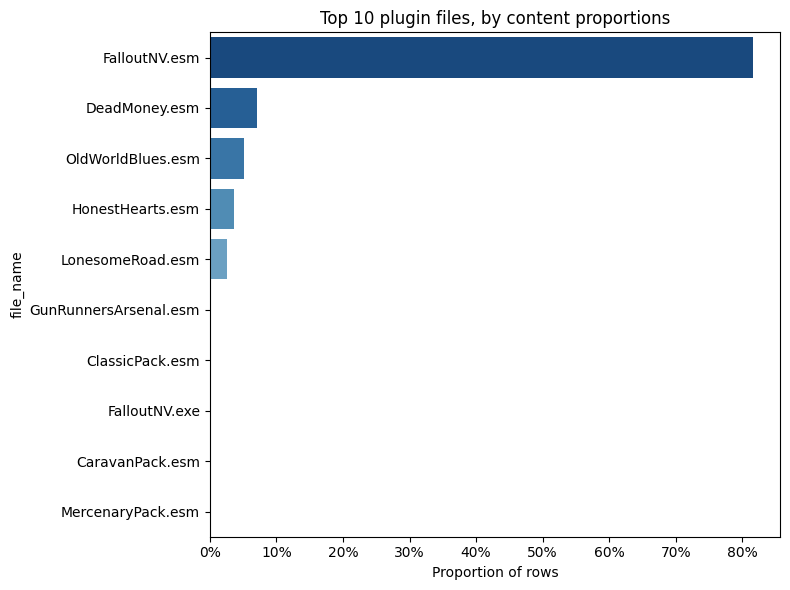

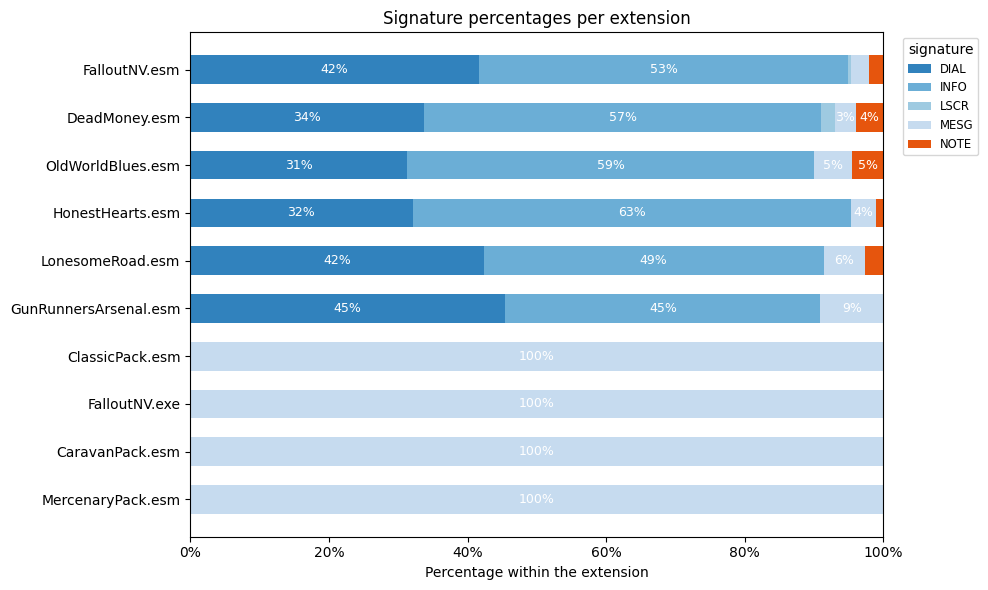

In [92]:
# Parameters
N_files = 10   # number of top files to show in stacked bars
M_sigs = 5     # top signatures per file to show
K = 10         # number of top file_name proportions to show


file_totals = df["file_name"].value_counts()
top_files = file_totals.nlargest(N_files).index.tolist()

# --- distribution of file_name weights (overall) ---
fig2, ax2 = plt.subplots(figsize=(8, 6))
file_prop = (file_totals / file_totals.sum()).nlargest(K)
sns.barplot(x=file_prop.values, y=file_prop.index, palette="Blues_r", ax=ax2)
ax2.set_xlabel("Proportion of rows")
ax2.xaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_title(f"Top {K} plugin files, by content proportions")
plt.tight_layout()
plt.show()

# --- stacked horizontal percent bars per file ---
sig_within = (
    df[df["file_name"].isin(top_files)]
    .groupby(["file_name", "signature"])
    .size()
    .reset_index(name="count")
)
sig_within = sig_within.sort_values(
    ["file_name", "count"], ascending=[True, False])
sig_within = sig_within.groupby("file_name").head(M_sigs)
sig_within = sig_within.merge(file_totals.rename(
    "file_total"), left_on="file_name", right_index=True)
sig_within["pct_within"] = sig_within["count"] / sig_within["file_total"]

pivot = sig_within.pivot(
    index="file_name", columns="signature", values="pct_within").fillna(0)
pivot = pivot.reindex(top_files)

fig, ax = plt.subplots(figsize=(10, max(4, 0.6 * len(top_files))))
left = np.zeros(len(pivot))
colors = sns.color_palette("tab20c", n_colors=len(pivot.columns))

for i, col in enumerate(pivot.columns):
    vals = pivot[col].values
    ax.barh(pivot.index, vals, left=left,
            color=colors[i], label=str(col), height=0.6)
    left += vals

for yi, fname in enumerate(pivot.index):
    cum = 0.0
    for col in pivot.columns:
        val = pivot.loc[fname, col]
        if val > 0.03:  # label threshold (3%)
            ax.text(cum + val / 2, yi, f"{val:.0%}", va="center",
                    ha="center", color="white", fontsize=9)
        cum += val

ax.set_xlabel("Percentage within the extension")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(title="signature", bbox_to_anchor=(
    1.02, 1), loc="upper left", fontsize="small")
plt.title("Signature percentages per extension")
plt.tight_layout()

The main game file (`FalloutNV.esm`) is the one with most content, extensions are less significant in terms of content quantity and there is quite a difference between them.

`INFO` and `DIAL` are the signatures with most content.

## <a id='toc1_5_'></a>[IV. Data quality & cleaning](#toc0_)
### <a id='toc1_5_1_'></a>[A. Missing values](#toc0_)
- Per-column counts & percent:

In [93]:
mv = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean()*100
}).sort_values("missing_pct", ascending=True)
display(mv)

,missing_count,missing_pct
signature,0,0.000000
file_name,0,0.000000
formID,0,0.000000
topLevelPath,0,0.000000
text_content,148,0.276279
content_source,148,0.276279
name,1480,2.762792
topic,1851,3.455357
quest,24530,45.791409
editorID,28934,54.012582


- Per-row missingness pattern & visualization:

Text(0.5, 1.0, 'Missingness map')

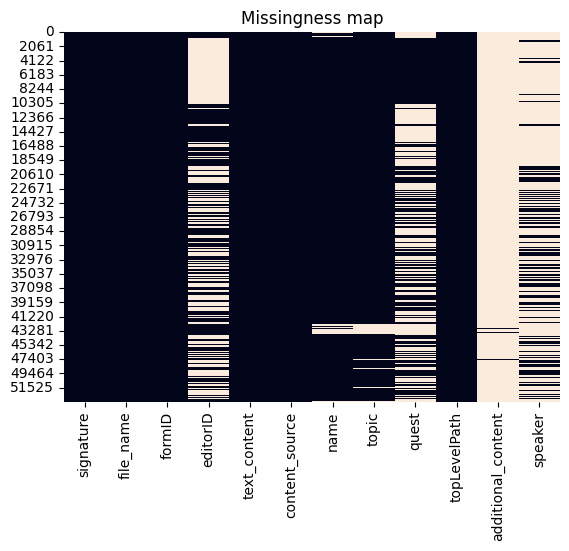

In [94]:
sns.heatmap(df.isna(), cbar=False)
plt.title("Missingness map")

- Grouped by signature counts and missingness:

In [95]:
grp = df.groupby("signature").agg({
    "text_content": ["count", lambda x: x.isna().mean()],
    "file_name": "nunique"
})
grp.columns = ["count", "text_missing_frac", "n_file_names"]
grp = grp.sort_values("count", ascending=False)
display(grp.head())

,count,text_missing_frac,n_file_names
signature,,,
INFO,28924,0.000311,6
DIAL,21522,0.001763,6
MESG,1535,0.021046,11
NOTE,1157,0.055510,5
LSCR,283,0.000000,2


In [96]:
# TODO - IMPLEMENT MISSINGNESS PER SIG. HERE

### <a id='toc1_5_2_'></a>[B. Duplicates](#toc0_)
- Full-row duplicates:

In [97]:
full_dup_count = df.duplicated(keep=False).sum()
display(full_dup_count)

np.int64(0)

No duplicate rows.

- Duplicate turns per signature:

Rows where duplicate combined signature & text_content appear more than once.

In [98]:
dupe_mask = df[["signature", "text_content"]].duplicated(keep=False)
turn_dup = df[["signature", "text_content"]].duplicated(keep=False).sum()
display(turn_dup)

np.int64(10061)

More than 10k values! This is significant and should be considered for some tasks (bias risk). Let's check top recurring contents.

In [99]:
dupe_groups = (df[dupe_mask]
               .groupby(["signature", "text_content"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))
display(dupe_groups.head(10))

,signature,text_content,count
186,DIAL,Goodbye.,479
514,DIAL,Let's talk about something else.,155
2297,INFO,You got it. Best of luck and enjoy the carnage.,87
1311,INFO,Done.,80
261,DIAL,I don't have enough caps right now.,75
2351,INFO,Your loss. Come back to me when you have somet...,70
2021,INFO,The Thorn's thirsty for blood. Pay my costs an...,63
552,DIAL,Never mind.,59
951,DIAL,Who are you?,46
1050,INFO,,39


### <a id='toc1_5_3_'></a>[C. Inconsistent types / text cleaning checks](#toc0_)
- Non-UTF8 / encoding issues: handled on read; detect control chars & high unicode:

In [100]:
control_chars = df["text_content"].fillna(
    "").str.contains(r"[\x00-\x1f\x7f-\x9f]")
control_chars.sum()

np.int64(1021)

Control characters (e.g., NUL, BEL, TAB, LF) are non-printables and can cause display, parsing, or tokenization problem.

- Leading/trailing whitespace, multiple spaces:

In [101]:
ws_counts = df["text_content"].fillna("").str.match(r"^\s+") .sum()

In [102]:
# compute counts / masks
ws_counts = df["text_content"].fillna("").str.match(r"^\s+").sum()

print("leading-whitespace rows count:", int(ws_counts))

print("\nSamples with leading whitespace:")
display(df[df["text_content"].fillna("").str.match(r"^\s+")].head(2))

leading-whitespace rows count: 72

Samples with leading whitespace:


,signature,file_name,formID,editorID,text_content,content_source,name,topic,quest,topLevelPath,additional_content,speaker
256,NOTE,FalloutNV.esm,0011DD96,V21History01,\r\nVault 21 has a story unlike any other Nucl...,TNAM - Text / Topic,A Story to Be Told,Text,NaN,\ [00] FalloutNV.esm \ [44] Note \ [256] V21H...,NaN,NaN
638,NOTE,FalloutNV.esm,000A6123,FFEnclaveEncampment12A,...,TNAM - Text / Topic,Camp Crater Orientation,Text,NaN,\ [00] FalloutNV.esm \ [44] Note \ [638] FFEn...,NaN,NaN


- Another element to consider is the *paratext* present in some of the content:
  
  These are text elements usually embedded within the content that adds informational value to the text lines.

*Examples:*

- {Drunk, stumbling home}Can barely see the street.
- [SUCCEEDED] So you weighed the value of confirming if..
- < Lie > No, Williams didn't tell me anything.

This can bias some analyses/models.

In [103]:
# text column has strings
s = df["text_content"].fillna("").astype(str)

# mask: rows containing any bracketed content
pattern_any = r"[\[\{\<][^\]\}\>]+[\]\}\>]"
rows_with_any = s.str.contains(pattern_any, regex=True)
print("Rows containing any bracketed text:", int(rows_with_any.sum()))

# count total occurrences across the column (sum of counts per row)
pattern_all = re.compile(r"[\[\{\<][^\]\}\>]+[\]\}\>]")
total_occurrences = s.map(lambda t: len(pattern_all.findall(t))).sum()
print("Total bracketed occurrences:", int(total_occurrences))

# breakdown by bracket type (rows and occurrences)
patterns = {
    "square []": r"\[[^\]]+\]",
    "curly {}": r"\{[^}]+\}",
    "angle <>": r"\<[^>]+\>",
}
for name, pat in patterns.items():
    mask = s.str.contains(pat, regex=True)
    occ = s.map(lambda t, p=re.compile(pat): len(p.findall(t))).sum()
    print(f"{name} — rows: {int(mask.sum())}, occurrences: {int(occ)}")

Rows containing any bracketed text: 10937
Total bracketed occurrences: 15159
square [] — rows: 2021, occurrences: 2258
curly {} — rows: 8410, occurrences: 11639
angle <> — rows: 1256, occurrences: 1275


### <a id='toc1_5_4_'></a>[D. Cleaning pipeline](#toc0_)

- Lowercase, normalize unicode, remove control chars, replace multiple spaces, strip, handle paratext.

In [104]:
BRACKET_PATTERNS = {
    "angle": re.compile(r"<[^<>]+>"),
    "square": re.compile(r"\[[^\[\]]+\]"),
    "curly":  re.compile(r"\{[^{}]+\}"),
}
ANY_BRACKET = re.compile(r"(<[^<>]+>|\[[^\[\]]+\]|\{[^{}]+\})")

# control chars (C0 and C1) except common whitespace we want to keep (tab/newline/return)
CTRL_RE = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]")

# replacement char
REPL_CHAR = "\uFFFD"


def extract_paratext_and_clean(df, text_col="text_content",
                               out_text="cleaned_text", out_para="paratext"):
    """
    Creates two columns:
      - out_para: concatenated paratext snippets (removed from text)
      - out_text: cleaned main text (lowercased, unicode-normalized, ctrl chars removed,
                  quotes removed, replacement char removed, multi-space collapsed)
    """
    def normalize_and_clean(text):
        text = "" if text is None else str(text)

        # normalize unicode
        text = unicodedata.normalize("NFC", text)

        # remove replacement chars early (won't appear in extracted paratext)
        text = text.replace(REPL_CHAR, "")

        # extract paratext snippets in order
        paratexts = ANY_BRACKET.findall(text)
        para_joined = " ".join([p.strip()
                               for p in paratexts]) if paratexts else ""

        # remove all paratext occurrences from the text
        text_no_para = ANY_BRACKET.sub(" ", text)

        # remove control characters
        text_no_ctrl = CTRL_RE.sub("", text_no_para)

        # remove quotes (double, single, smart)
        text_no_quotes = (text_no_ctrl
                          .replace('"', '')
                          .replace("“", "")
                          .replace("”", ""))

        # collapse whitespace and strip
        text_collapsed = re.sub(r"\s+", " ", text_no_quotes).strip()

        # lowercase
        text_final = text_collapsed.lower()

        # also clean paratext content of replacement chars and surrounding whitespace
        cleaned_paras = []
        for p in paratexts:
            p_clean = p.replace(REPL_CHAR, "").strip()
            if p_clean:
                cleaned_paras.append(p_clean)
        para_joined = " ".join(cleaned_paras)

        return text_final, para_joined

    s = df[text_col].fillna("").astype(str)
    results = s.map(normalize_and_clean)
    df[out_text] = results.map(lambda x: x[0])
    df[out_para] = results.map(lambda x: x[1])

    return df

In [105]:
extract_paratext_and_clean(df)
display(df.head(2))

,signature,file_name,formID,editorID,text_content,content_source,name,topic,quest,topLevelPath,additional_content,speaker,cleaned_text,paratext
0,NOTE,FalloutNV.esm,00177875,vYesManBunkerNote,Have I told you lately that youï¿½re my favori...,TNAM - Text / Topic,About that Bunker at Fortification Hill...,Text,NaN,\ [00] FalloutNV.esm \ [44] Note \ [0] vYesMa...,NaN,NaN,have i told you lately that youï¿½re my favori...,
1,NOTE,FalloutNV.esm,00175AB0,RecipesCookCooksFiendStewNote,This recipe allows you to make Cook-Cook's Fie...,TNAM - Text / Topic,Recipes - Cook-Cook's Fiend Stew,Text,NaN,\ [00] FalloutNV.esm \ [44] Note \ [1] Recipe...,NaN,NaN,this recipe allows you to make cook-cook's fie...,


## <a id='toc1_6_'></a>[V. Text statistics](#toc0_)

- Text length distributions (characters) overall, per signature, per file_name:


<Axes: xlabel='char_len', ylabel='Count'>

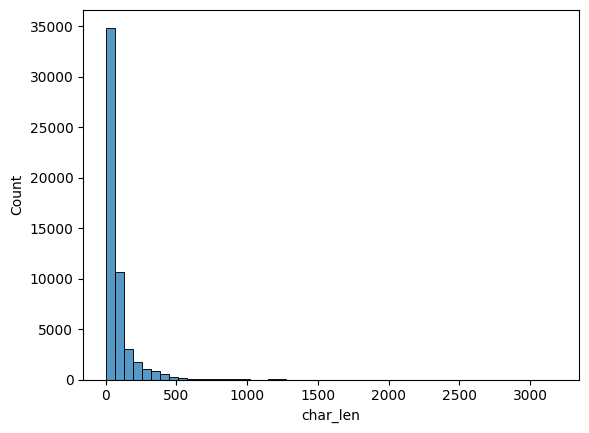

In [106]:
df["char_len"] = df['cleaned_text'].fillna("").str.len()
df['token_count'] = df['cleaned_text'].fillna("").str.split().map(len)
df[['char_len', 'token_count']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99])
sns.histplot(df['char_len'], bins=50)

The histogram exhibits a clear right-skewness, meaning that the bulk of the data is concentrated on the left side, with a long tail extending to the right. Most entries have relatively short character lengths, while a few have much longer lengths.

- Outliers:


In [107]:
long_outliers = df.nlargest(10, 'char_len')[
    ['signature', 'file_name', 'char_len', 'cleaned_text']]
short_outliers = df[df['char_len'] <= 3]
long_outliers

,signature,file_name,char_len,cleaned_text
52,NOTE,FalloutNV.esm,3188,building a deck caravan decks are comprised of...
42663,MESG,FalloutNV.esm,2765,most game play in caravan occurs during the co...
436,NOTE,FalloutNV.esm,2710,"prepared speech of gus olson, ombudsman, for t..."
51622,NOTE,HonestHearts.esm,2672,"january 2nd i've been leaving notes for them, ..."
43900,NOTE,DeadMoney.esm,2666,"vera, if you're reading this, my fears have co..."
42583,MESG,FalloutNV.esm,2533,blackjack is a game played with one more stand...
34,NOTE,FalloutNV.esm,2425,"robert edwin house, 261, president, ceo, and s..."
459,NOTE,FalloutNV.esm,2401,can i tell him? a poseidon energy publication ...
21810,INFO,FalloutNV.esm,2392,"wahoo, you did it pardner! bully for you! ol' ..."
23355,INFO,FalloutNV.esm,2188,"i can provide a quick history lesson, if that'..."


No surprize, long content comes usually from notes or messages.

We cannot really talk about outliers here. The dataset is a collection of various types of in-game text contents (dialogues, notes..) and these intrisic differences will need to be considered depending on the use-cases. 

- Aggregated per signature:


In [108]:
agg_sig = df.groupby('signature').agg({
    'char_len': ['sum', 'mean', 'median', 'max', 'min'],
    'token_count': ['sum', 'mean']
})
agg_sig

char_len                              token_count           
               sum        mean median   max min         sum       mean
signature                                                             
DIAL        742535   34.440399   31.0   100   0      132249   6.133998
INFO       2769967   95.737290   63.0  2392   0      512210  17.703315
LSCR         36274  128.176678  123.0   248  56        6096  21.540636
MESG        187011  119.267219   67.0  2765   0       32426  20.679847
NOTE        443604  362.125714  299.0  3188   0       77090  62.930612

`DIAL`and `INFO` text is shorter than text extracted in `LSCR` and `NOTE`. This makes sense, since Dialogues (`INFO` is a subgroup of `DIAL`) are tipically shorter than loading screen and in-game notes.

Let's dig a bit further to see if there are interesting observations at a plugin level.

In [109]:
agg_by_file_sig = df.groupby(['file_name', 'signature']).agg({
    'char_len': ['sum', 'mean', 'median', 'max', 'min'],
    'token_count': ['sum', 'mean']
})
agg_by_file_sig

char_len                               \
                                     sum        mean median   max min   
file_name             signature                                         
CaravanPack.esm       MESG            38   38.000000   38.0    38  38   
ClassicPack.esm       MESG            89   44.500000   44.5    51  38   
DeadMoney.esm         DIAL         48569   38.333860   35.0   100   0   
                      INFO        200290   93.114830   60.0  1084   0   
                      LSCR          8957  119.426667  119.0   179  64   
                      MESG         10617   92.321739   66.0   573   0   
                      NOTE         43309  292.628378  237.5  2666   0   
FalloutNV.esm         DIAL        610258   33.503047   30.0   100   0   
                      INFO       2182764   93.894438   63.0  2392   0   
                      LSCR         27317  131.331731  125.5   248  56   
                      MESG        145812  127.458042   69.5  2765   0   
                      NOTE        340425  380.788591  307.5  3188   0   
FalloutNV.exe         MESG             0    0.000000    0.0     0   0   
GunRunnersArsenal.esm DIAL           334   33.400000   32.0    42  24   
                      INFO           319   31.900000   28.0    62  10   
                      MESG           312  156.000000  156.0   275  37   
HonestHearts.esm      DIAL         21550   34.315287   29.0    99   0   
                      INFO        122502   98.951535   45.0   840   0   
                      MESG          6573   92.577465   66.0   301   0   
                      NOTE         18946  902.190476  802.0  2672   0   
LonesomeRoad.esm      DIAL         26688   46.413913   47.0   100   0   
                      INFO         90172  135.190405   75.0  1643   0   
                      MESG         10791  134.887500   78.5   758  24   
                      NOTE          8537  230.729730  273.0   501   0   
MercenaryPack.esm     MESG            40   40.000000   40.0    40  40   
OldWorldBlues.esm     DIAL         35136   40.619653   38.0   100   0   
                      INFO        173920  107.358025   76.0  1137   0   
                      MESG         12702   84.680000   56.5   586   0   
                      NOTE         32387  259.096000  240.0   739   0   
TribalPack.esm        MESG            37   37.000000   37.0    37  37   

                                token_count              
                                        sum        mean  
file_name             signature                          
CaravanPack.esm       MESG                6    6.000000  
ClassicPack.esm       MESG               16    8.000000  
DeadMoney.esm         DIAL             8279    6.534333  
                      INFO            36897   17.153417  
                      LSCR             1501   20.013333  
                      MESG             1850   16.086957  
                      NOTE             7601   51.358108  
FalloutNV.esm         DIAL           109162    5.992973  
                      INFO           405355   17.436874  
                      LSCR             4595   22.091346  
                      MESG            25438   22.236014  
                      NOTE            59143   66.155481  
FalloutNV.exe         MESG                0    0.000000  
GunRunnersArsenal.esm DIAL               66    6.600000  
                      INFO               63    6.300000  
                      MESG               48   24.000000  
HonestHearts.esm      DIAL             3853    6.135350  
                      INFO            22811   18.425687  
                      MESG             1141   16.070423  
                      NOTE             3473  165.380952  
LonesomeRoad.esm      DIAL             4782    8.316522  
                      INFO            16350   24.512744  
                      MESG             1849   23.112500  
                      NOTE             1412   38.162162  
MercenaryPack.esm     MESG                6    6.000000 

For example, in the *Honest Hearts* extension, Notes are much longer than the usual. Does this involve a different narrative structure with a game design emphasizong notes? It could be interesting to find out why.

- Sentence counts & avg sentence length:

In [110]:
nltk.download('punkt')
nltk.download('punkt_tab')
df['n_sent'] = df['cleaned_text'].fillna("").apply(
    lambda s: len(sent_tokenize(s)) if s else 0)
df['avg_words_per_sent'] = df.apply(lambda r: (
    r['token_count']/r['n_sent']) if r['n_sent'] > 0 else r['token_count'], axis=1)
df[['n_sent', 'avg_words_per_sent']].describe()

[nltk_data] Downloading package punkt to /home/draught/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/draught/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,n_sent,avg_words_per_sent
count,53569.000000,53569.000000
mean,1.656368,7.517245
std,1.416946,6.762808
min,0.000000,0.000000
25%,1.000000,3.250000
50%,1.000000,6.000000
75%,2.000000,10.000000
max,59.000000,111.000000


- Vocabulary & TTR:
(number of tokens that occur exactly once)

In [111]:
tokens = df['cleaned_text'].dropna().str.split().explode()
vocab = Counter(tokens)
vocab_size = len(vocab)
ttr = vocab_size / tokens.count()
hapax = sum(1 for v in vocab.values() if v == 1)
hapax_pct = hapax / vocab_size
display(vocab_size,ttr,hapax,hapax_pct)

54002

np.float64(0.0710486257204919)

31331

0.580182215473501

vocab_size = 53,378 tokens, about 7.02% of tokens are unique types and 58% of the vocabulary are hapax legomena (occur exactly once).

- Frequent tokens & zipf plot:


Text(0.5, 1.0, 'Zipf plot')

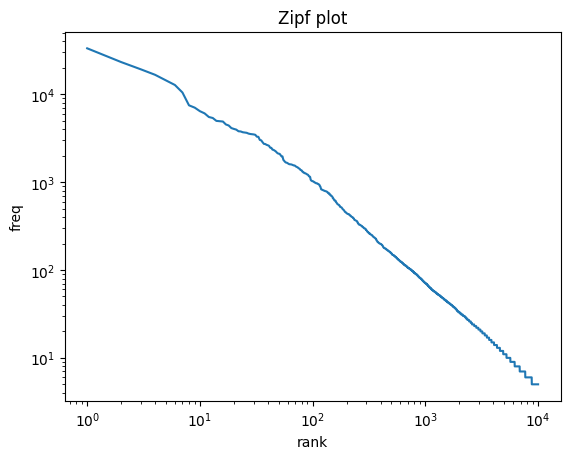

In [112]:
topk = vocab.most_common(50)
# zipf: rank vs log freq
freqs = np.array([f for _, f in vocab.most_common(10000)])
ranks = np.arange(1, len(freqs)+1)
plt.loglog(ranks, freqs)
plt.xlabel('rank')
plt.ylabel('freq')
plt.title('Zipf plot')

This diagnose corpus conformity to Zipf’s law: you typically see an approximately straight line with slope ≈ −1, indicating frequency ≈ constant / rank.
Usually, deviations at low ranks show stopword/artifact effects; deviations in the tail show richness/rarity.

In short: 
A small subset of elements is responsible for the majority of occurrences. A few words like "the" or "and" are used far more than others. Let's prove it below:

In [113]:
display(topk[:8])

[('the', 33316),
 ('to', 23246),
 ('you', 19190),
 ('i', 16650),
 ('a', 14353),
 ('of', 12747),
 ('and', 10469),
 ('in', 7483)]

Of course most common tokens are **stopwords**. This has implications for language processing strategies to be deployed further.

Let's try removing some stopwords. We keep using **nltk** for simplicity, but **Spacy** is more robust and might be used instead in the following parts.

In [114]:
nltk.download('stopwords')  # run once
stop = set(stopwords.words('english'))

def remove_stops(text):
    if pd.isna(text):
        return text
    return " ".join(w for w in text.split() if w.lower() not in stop)


df['clean_no_stops'] = df['cleaned_text'].apply(remove_stops)

# build overall token list and get most common
tokens = []
for t in df['clean_no_stops'].dropna():
    tokens.extend(t.split())

most_common = Counter(tokens).most_common(20)
display("Most common words:", most_common)

# Export to CSV
df.to_csv('df_processed_notebook1.csv', index=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/draught/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'Most common words:'

[('like', 3021),
 ('get', 2839),
 ('-', 2722),
 ('got', 2327),
 ('know', 2107),
 ('one', 1962),
 ('you.', 1744),
 ('it.', 1643),
 ("that's", 1600),
 ('think', 1587),
 ('want', 1548),
 ('need', 1548),
 ('going', 1532),
 ('see', 1506),
 ('take', 1466),
 ('good', 1438),
 ('back', 1374),
 ('ncr', 1311),
 ('would', 1283),
 ('make', 1282)]

**That's it for now..**

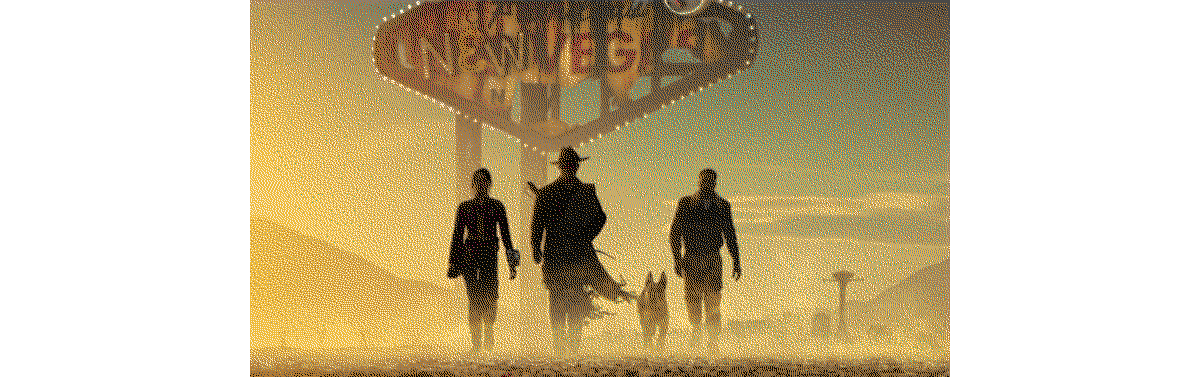

> “Stick around, kid. This is only the beginning.”
> Run the cells above, keep the flavor, and in nex episode, we’ll start mining quests, factions, and character arcs like a proper Wasteland prospector.

## <a id='toc1_7_'></a>[Acknowledgments ☢](#toc0_)
To all the people behind the [Fallout games](https://en.wikipedia.org/wiki/Fallout_(franchise)), thanks for offering this amazing journey for decades! Many kudos to the [Fallout modding community](https://www.nexusmods.com/newvegas/mods/) who built tools like [FNVEdit](https://tes5edit.github.io/) that allowed me to test myself on some text-mining.

Been learning a lot on this nuclear journey! 🤯

 Merci! ٭ Done in AnaFeb. 2026 by [brk](github.com/brooks-code).

Reste douce. 🐤